# When IPCW Matters A Lot

This notebook uses the same three implemented methods, but changes the data-generating condition to **very heavy independent censoring**. In this regime, the unweighted observed error `Delta * 1{Y < L}` is much smaller than the latent lower-bound error `1{T < L}` because many early failures are hidden by censoring.

IPCW corrects this by replacing the unweighted observed error with `Delta / G(Y) * 1{Y < L}`.

In [6]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from online_survival.experiments import (
    SimulationConfig,
    behavior_svg,
    fixed_rule_bias_diagnostic,
    format_markdown_table,
    run_one_experiment,
    run_repeated_experiments,
    summarize_one_run,
    summarize_repeats,
)


def show_markdown(markdown):
    try:
        from IPython.display import Markdown, display
        display(Markdown(markdown))
    except Exception:
        print(markdown)


def show_svg(svg):
    try:
        from IPython.display import SVG, display
        display(SVG(svg))
    except Exception:
        print(svg[:1000])

## Heavy-Censoring Setup

The censoring rate is set to `0.60`, which produces roughly 75-78% censored rounds in this synthetic problem. The target lower coverage is still `1 - alpha = 0.90`.

In [7]:
config = SimulationConfig(
    n_rounds=1000,
    alpha=0.10,
    tau_max=0.50,
    eta=0.008,
    model_log_shift=0.30,
    censoring_rate=0.60,
)

config

SimulationConfig(n_rounds=1000, alpha=0.1, tau_max=0.5, eta=0.008, tau_min=1e-06, x_low=-1.0, x_high=1.0, true_intercept=1.0, true_slope=0.35, true_sigma=0.55, model_log_shift=0.3, model_sigma=0.55, censoring_rate=0.6)

## Why the Unweighted Method Fails Here

Before running the adaptive methods, keep the lower-bound rule fixed at the nominal `tau = alpha`. The latent error is much larger than the target, but the unweighted observed error looks close to the target because censoring hides many failures. The IPCW error recovers the latent scale.

In [8]:
diagnostic = fixed_rule_bias_diagnostic(config, seed=17, tau=config.alpha)
show_markdown(format_markdown_table(diagnostic, digits=4))

| quantity | mean | target |
| --- | --- | --- |
| latent error 1{T < L} | 0.2300 | 0.1000 |
| unweighted observed error Delta * 1{Y < L} | 0.7310 | 0.1000 |
| IPCW error Delta/G(Y) * 1{Y < L} | 0.2378 | 0.1000 |
| censoring fraction | 0.7660 |  |

## One Run

On the same heavy-censoring stream, ACI without IPCW tends to keep the played quantile too high because it sees too few observed failures. IPCW ACI moves more aggressively toward smaller lower quantiles.

| algorithm | realized_coverage | average_conditional_coverage | average_surrogate_error | final_tau | censoring_fraction |
| --- | --- | --- | --- | --- | --- |
| ACI with IPCW | 0.8850 | 0.8789 | 0.1061 | 0.0504 | 0.7660 |
| ACI without IPCW | 0.9870 | 0.9891 | 0.2960 | 0.0016 | 0.7660 |
| AdaFTRL | 0.8630 | 0.8543 | 0.1182 | 0.0511 | 0.7660 |

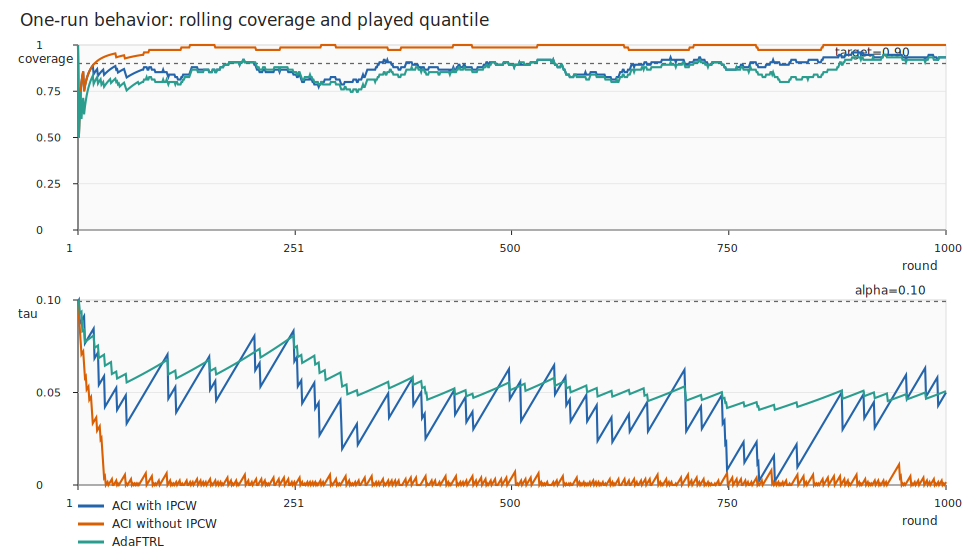

In [9]:
one_run = run_one_experiment(config, seed=17)

one_run_columns = [
    "algorithm",
    "realized_coverage",
    "average_conditional_coverage",
    "average_surrogate_error",
    "final_tau",
    "censoring_fraction",
]
show_markdown(format_markdown_table(summarize_one_run(one_run), one_run_columns, digits=4))
show_svg(behavior_svg(one_run, window=75))

## Repeated Experiments

The repeated experiment uses the same condition with different random seeds. The gap between ACI with IPCW and ACI without IPCW is the main point of this notebook.

In [10]:
repeated = run_repeated_experiments(config, n_repeats=100, seed=2026)
summary = summarize_repeats(repeated)

summary_columns = [
    "algorithm",
    "realized_coverage_mean",
    "realized_coverage_se",
    "average_conditional_coverage_mean",
    "average_conditional_coverage_se",
    "average_surrogate_error_mean",
    "final_tau_mean",
    "censoring_fraction_mean",
]
show_markdown(format_markdown_table(summary, summary_columns, digits=4))

| algorithm | realized_coverage_mean | realized_coverage_se | average_conditional_coverage_mean | average_conditional_coverage_se | average_surrogate_error_mean | final_tau_mean | censoring_fraction_mean |
| --- | --- | --- | --- | --- | --- | --- | --- |
| ACI with IPCW | 0.8922 | 0.0009 | 0.8924 | 0.0013 | 0.1086 | 0.0370 | 0.7748 |
| ACI without IPCW | 0.9897 | 0.0003 | 0.9903 | 0.0001 | 0.3097 | 0.0013 | 0.7748 |
| AdaFTRL | 0.8729 | 0.0009 | 0.8732 | 0.0012 | 0.1280 | 0.0372 | 0.7748 |